In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Rectangle
import numpy as np


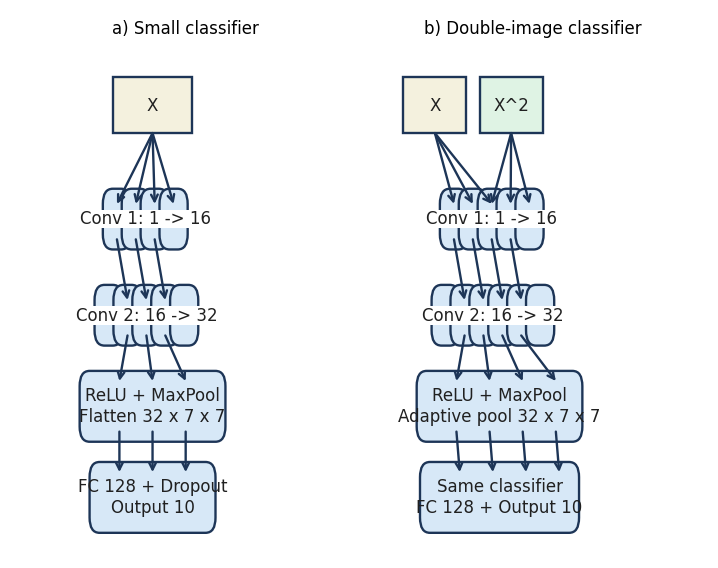

In [7]:
plt.rcParams.update({
    "font.size": 6,
    "axes.titlesize": 6,
    "axes.labelsize": 6,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "legend.fontsize": 6,
})

fig, axes = plt.subplots(1, 2, figsize=(3.45, 2.7), dpi=200)

layer_face = "#d7e8f7"
image_face = "#f4f1de"
square_face = "#dff3e4"
accent = "#1d3557"
text_color = "#202020"


def draw_box(ax, xy, width, height, label, facecolor, fontsize=6):
    patch = FancyBboxPatch(
        xy,
        width,
        height,
        boxstyle="round,pad=0.02,rounding_size=0.03",
        linewidth=0.85,
        edgecolor=accent,
        facecolor=facecolor,
    )
    ax.add_patch(patch)
    ax.text(
        xy[0] + width / 2,
        xy[1] + height / 2,
        label,
        ha="center",
        va="center",
        fontsize=fontsize,
        color=text_color,
    )


def draw_arrow(ax, start, end):
    ax.annotate(
        "",
        xy=end,
        xytext=start,
        arrowprops=dict(arrowstyle="->", lw=0.85, color=accent, shrinkA=0, shrinkB=0),
    )


def image_pattern():
    grid = np.linspace(0, 1, 8)
    return 0.5 + 0.35 * np.outer(np.sin(np.pi * grid), np.cos(np.pi * grid[::-1]))


def draw_image_block(ax, x0, y0, width, height, label, facecolor, data):
    ax.add_patch(Rectangle((x0, y0), width, height, facecolor=facecolor, edgecolor=accent, linewidth=0.85))
    ax.imshow(
        data,
        extent=(x0, x0 + width, y0, y0 + height),
        cmap="Greys",
        alpha=0.55,
        origin="lower",
        interpolation="nearest",
        aspect="auto",
    )
    ax.text(x0 + width / 2, y0 + height / 2, label, ha="center", va="center", color=text_color)


def draw_conv_row(ax, x0, y0, count, box_w, box_h, gap, label):
    xs = []
    total_w = count * box_w + (count - 1) * gap
    label_x = x0 + total_w / 2
    label_y = y0 + box_h / 2
    for i in range(count):
        xi = x0 + i * (box_w + gap)
        xs.append(xi + box_w / 2)
        draw_box(ax, (xi, y0), box_w, box_h, "", layer_face, fontsize=6)
    ax.text(
        label_x,
        label_y,
        label,
        ha="center",
        va="center",
        color=text_color,
        bbox=dict(facecolor="white", edgecolor="none", pad=0.15),
    )
    return xs, label_y + 0.03, y0


def format_panel(ax, title):
    ax.set_title(title, pad=3)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")


pattern = image_pattern()
input_y = 0.82
conv1_y = 0.61
conv2_y = 0.42
pool_y = 0.23
fc_y = 0.05
conv_box_h = 0.08
conv_box_w = 0.045
conv_gap = 0.012
layer_h = 0.1

format_panel(axes[0], "a) Small classifier")
draw_image_block(axes[0], 0.28, input_y, 0.24, 0.11, "X", image_face, pattern)
conv1_xs, conv1_label_y, conv1_box_top = draw_conv_row(axes[0], 0.27, conv1_y, 4, conv_box_w, conv_box_h, conv_gap, "Conv 1: 1 -> 16")
conv2_xs, conv2_label_y, conv2_box_top = draw_conv_row(axes[0], 0.245, conv2_y, 5, conv_box_w, conv_box_h, conv_gap, "Conv 2: 16 -> 32")
draw_box(axes[0], (0.2, pool_y), 0.4, layer_h, "ReLU + MaxPool\nFlatten 32 x 7 x 7", layer_face)
draw_box(axes[0], (0.23, fc_y), 0.34, layer_h, "FC 128 + Dropout\nOutput 10", layer_face)
for x_end in conv1_xs:
    draw_arrow(axes[0], (0.4, input_y), (x_end, conv1_label_y))
for x_start in conv1_xs[:3]:
    draw_arrow(axes[0], (x_start, conv1_y), (conv2_xs[conv1_xs.index(x_start) + 1], conv2_label_y))
for x_start, x_end in zip(conv2_xs[1:4], [0.3, 0.4, 0.5]):
    draw_arrow(axes[0], (x_start, conv2_y), (x_end, pool_y + layer_h))
for x_start, x_end in zip([0.3, 0.4, 0.5], [0.3, 0.4, 0.5]):
    draw_arrow(axes[0], (x_start, pool_y), (x_end, fc_y + layer_h))

format_panel(axes[1], "b) Double-image classifier")
draw_image_block(axes[1], 0.11, input_y, 0.19, 0.11, "X", image_face, pattern)
draw_image_block(axes[1], 0.34, input_y, 0.19, 0.11, "X^2", square_face, pattern**2)
conv1b_xs, conv1b_label_y, conv1b_box_top = draw_conv_row(axes[1], 0.24, conv1_y, 5, conv_box_w, conv_box_h, conv_gap, "Conv 1: 1 -> 16")
conv2b_xs, conv2b_label_y, conv2b_box_top = draw_conv_row(axes[1], 0.215, conv2_y, 6, conv_box_w, conv_box_h, conv_gap, "Conv 2: 16 -> 32")
draw_box(axes[1], (0.17, pool_y), 0.46, layer_h, "ReLU + MaxPool\nAdaptive pool 32 x 7 x 7", layer_face)
draw_box(axes[1], (0.18, fc_y), 0.44, layer_h, "Same classifier\nFC 128 + Output 10", layer_face)
for x_end in conv1b_xs[:3]:
    draw_arrow(axes[1], (0.205, input_y), (x_end, conv1b_label_y))
for x_end in conv1b_xs[2:]:
    draw_arrow(axes[1], (0.435, input_y), (x_end, conv1b_label_y))
for x_start, x_end in zip(conv1b_xs[:4], conv2b_xs[1:5]):
    draw_arrow(axes[1], (x_start, conv1_y), (x_end, conv2b_label_y))
for x_start, x_end in zip(conv2b_xs[1:5], [0.27, 0.37, 0.47, 0.57]):
    draw_arrow(axes[1], (x_start, conv2_y), (x_end, pool_y + layer_h))
for x_start, x_end in zip([0.27, 0.37, 0.47, 0.57], [0.28, 0.38, 0.48, 0.58]):
    draw_arrow(axes[1], (x_start, pool_y), (x_end, fc_y + layer_h))

plt.tight_layout(pad=0.35, w_pad=0.7)
plt.savefig("double_image_classifier_schemes.pdf", dpi=300)
plt.show()
